# Fig 1.b


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.font_manager import FontProperties
import pandas as pd
import seaborn as sns
from scipy.stats import linregress

font = FontProperties()
font.set_family("serif")
font.set_name("Times New Roman")

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]
sns.set(style="white")
sns.set_context("paper", rc={"font.size": 6, "axes.titlesize": 8, "axes.labelsize": 8})


def resolve_data_path() -> Path:
    candidates = [
        Path.cwd() / "data" / "c_individual_all_osm_home_15_place_15.parquet",
        Path.cwd().parent / "data" / "c_individual_all_osm_home_15_place_15.parquet",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not find data/c_individual_all_osm_home_15_place_15.parquet")


DATA_PATH = resolve_data_path()

In [2]:
MEASURES = [
    "resi_mix",
    "mixing_income_census",
    "mixing_primary",
    "mixing_place_census",
    "mixing_income_random",
]

colorcity_short = {
    "Sao Paulo": "#19967d",
    "Hong Kong": "#3bc0cf",
    "Chicago": "#fdb528",
    "London": "#0c7cba",
    "Boston": "#ef5c43",
}

df = pd.read_parquet(
    DATA_PATH,
    columns=["city_short", "hhcount", "age", "leg_count", *MEASURES],
)
df["city_abbr"] = df["city_short"].str[0].str.upper()
df["hhcount"] = df["hhcount"].fillna(0)
df["leg_count"] = df["leg_count"].fillna(0).astype(int)

hhcount = 5
viz = df[(df["hhcount"] >= hhcount) & (df["age"] > 11) & (df["leg_count"] > 0)].copy()
viz.groupby("city_short")[MEASURES].mean().round(3)


,resi_mix,mixing_income_census,mixing_primary,mixing_place_census,mixing_income_random
city_short,,,,,
Boston,0.570,0.656,0.734,0.757,0.905
Chicago,0.587,0.567,0.783,0.767,0.901
Hong Kong,0.725,0.707,0.895,0.900,0.967
London,0.712,0.519,0.795,0.763,0.914
Sao Paulo,0.558,0.583,0.731,0.803,0.904


In [ ]:
df.columns

Chicago R²=0.30
coef=0.30
p=0.000
Sao Paulo R²=0.41
coef=0.48
p=0.000
Hong Kong R²=0.14
coef=0.13
p=0.000
London R²=0.22
coef=0.29
p=0.000
Boston R²=0.63
coef=0.72
p=0.000


,city,r2,coef,p
0,Chicago,0.297174,0.295575,0.0
1,Sao Paulo,0.410740,0.479598,0.0
2,Hong Kong,0.135302,0.129285,0.0
3,London,0.217532,0.288141,0.0
4,Boston,0.634522,0.715762,0.0


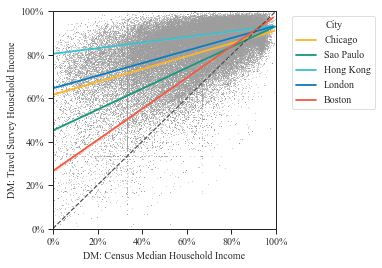

: 

In [ ]:
def plot_income_scatter(data: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(4, 4))
    x = "mixing_income_census"
    y = "mixing_primary"
    scatter_viz = data[(data[x] != "-1") & (data[x].notnull()) & (data[y].notnull())].reset_index(drop=True)

    sns.scatterplot(
        data=scatter_viz,
        x=x,
        y=y,
        alpha=0.5,
        s=1,
        color="grey",
        ax=ax,
    )

    stats = []
    for city in df["city_short"].unique():
        city_data = scatter_viz[scatter_viz["city_short"] == city]
        sns.regplot(
            data=city_data,
            x=x,
            y=y,
            scatter=False,
            color=colorcity_short[city],
            order=1,
            ci=95,
            label=city,
            ax=ax,
        )
        x_value = pd.to_numeric(city_data[x], errors="coerce")
        y_value = pd.to_numeric(city_data[y], errors="coerce")
        mask = x_value.notna() & y_value.notna()
        if mask.sum() > 1:
            res = linregress(x_value[mask], y_value[mask])
            textstr = f"R²={res.rvalue**2:.2f}\ncoef={res.slope:.2f}\np={res.pvalue:.3f}"
            print(city, textstr)
            stats.append({
                "city": city,
                "r2": res.rvalue**2,
                "coef": res.slope,
                "p": res.pvalue,
            })

    ax.plot([0, 1], [0, 1], transform=ax.transAxes, ls="--", c=".3")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("DM: Census Median Household Income", fontproperties=font)
    ax.set_ylabel("DM: Travel Survey Household Income", fontproperties=font)
    ax.yaxis.set_ticks_position("left")
    ax.xaxis.set_ticks_position("bottom")
    ax.legend(title="City", bbox_to_anchor=(1.05, 1), loc="upper left", prop=font)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontproperties(font)
    legend = ax.get_legend()
    if legend is not None:
        legend.get_title().set_fontproperties(font)
        for text in legend.get_texts():
            text.set_fontproperties(font)
    return fig, ax, pd.DataFrame(stats)


fig, ax, regression_stats = plot_income_scatter(viz)
regression_stats
